# Cyberbully Comment Detection — NLP Multi-Label Classification

**AI Assignment (Title 4: Natural Language Processing)**

Run the cells from **top to bottom** (Shift+Enter on each, or menu **Run → Run All Cells**).

| Member | Method |
|--------|--------|
| Member 1 | Naive Bayes + TF-IDF |
| Member 2 | Linear SVM + TF-IDF |
| Member 3 | BiLSTM (deep learning) |

> **Before you start:** open this notebook from *inside* the `cyberbully_detection`
> folder, and make sure you installed the libraries first (in Anaconda Prompt:
> `pip install -r requirements.txt`).

## Running in Google Colab?

If you're on your own computer (Anaconda/Jupyter), **skip this section** — go
straight to "0. Setup" below.

If you're in **Google Colab**: turn on the GPU first (`Runtime -> Change runtime
type -> T4 GPU -> Save`, needed only for the BiLSTM), then run the cell below.
It will ask you to upload `cyberbully_detection.zip` and will set everything up
automatically. You only need to do this once per Colab session.

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import os, zipfile
    from google.colab import files

    if not os.path.isdir("cyberbully_detection"):
        print("Please choose cyberbully_detection.zip in the upload box below...")
        uploaded = files.upload()
        zip_name = [f for f in uploaded if f.endswith(".zip")][0]
        with zipfile.ZipFile(zip_name) as z:
            z.extractall(".")
        print("Extracted.")

    os.chdir("cyberbully_detection")
    print("Now working in:", os.getcwd())

    # (Optional) keep your results after the Colab session ends by saving to
    # Google Drive instead. Uncomment the 3 lines below if you want this:
    # from google.colab import drive
    # drive.mount("/content/drive")
    # os.chdir("/content/drive/MyDrive/cyberbully_detection")

    print("Installing/upgrading a couple of packages Colab may be missing...")
    !pip install -q streamlit joblib
else:
    print("Not running in Colab - skipping upload step.")


Not running in Colab - skipping upload step.


## 0. Setup

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")
%matplotlib inline

print("Working directory:", os.getcwd())

# This notebook must run from the project root (the folder containing 'src', 'models', 'data').
# If the check below fails, set the correct path in os.chdir() and re-run this cell:
# os.chdir(r"C:\Users\YourName\Desktop\cyberbully_detection")

assert os.path.isdir("src") and os.path.isdir("data"), (
    "Not in the project root. Open the notebook from the cyberbully_detection folder, "
    "or set the path with os.chdir() above."
)
print("Setup OK - project root found.")

Working directory: C:\Users\lowli\cyberbully_detection
Setup OK - project root found.


## 1. Load data and preprocess text
This loads the HateXplain dataset, builds the 6 binary labels, cleans the text, and makes the train/test split. All three models share this same split so the comparison is fair.

In [3]:
from src.common import prepare_data

X_train, X_test, y_train, y_test, labels = prepare_data(data_dir="data")
print("\nLabels:", labels)
print("Train comments:", len(X_train), "| Test comments:", len(X_test))

Loaded file   : data\final_hateXplain.csv
Rows          : 20,109
Text column   : 'comment'
Label columns : ['abusive', 'Race', 'Religion', 'Gender', 'Sexual_Orientation', 'Miscellaneous']

Positive count per label:
abusive               12291
Race                   6530
Religion               4722
Gender                 3729
Sexual_Orientation     2282
Miscellaneous          3533

Comments with 2+ labels (multi-label): 12,097

Sample row:
comment               0 u0 lmao wow fuck you too 😂 😂
abusive                                            0
Race                                               0
Religion                                           0
Gender                                             0
Sexual_Orientation                                 0
Miscellaneous                                      0

Cleaning text ... (this can take a minute on the full dataset)
Train size: 16,086   Test size: 4,022

Labels: ['abusive', 'Race', 'Religion', 'Gender', 'Sexual_Orientation', 'Miscellane

## 2. Explore the data (EDA)
Charts for your documentation's *Methodology / Dataset* section.

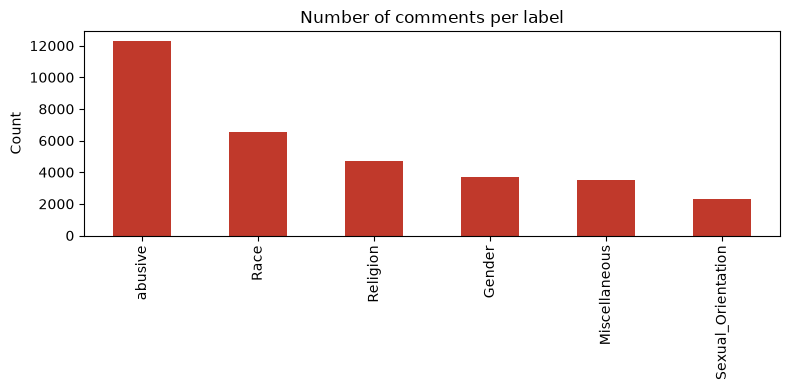

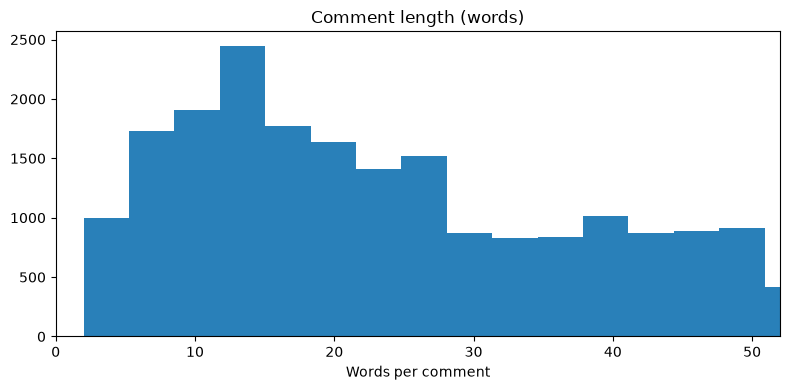

Total comments: 20109


In [4]:
import matplotlib.pyplot as plt
from src.data_loader import load_dataset

df_full, text_col, label_cols = load_dataset("data", verbose=False)

# (a) how many comments carry each label
counts = df_full[label_cols].sum().sort_values(ascending=False)
counts.plot(kind="bar", color="#c0392b", figsize=(8,4),
            title="Number of comments per label")
plt.ylabel("Count"); plt.tight_layout(); plt.show()

# (b) comment length distribution
lengths = df_full[text_col].astype(str).str.split().apply(len)
plt.figure(figsize=(8,4))
plt.hist(lengths, bins=50, color="#2980b9")
plt.title("Comment length (words)"); plt.xlabel("Words per comment")
plt.xlim(0, lengths.quantile(0.99)); plt.tight_layout(); plt.show()

print("Total comments:", len(df_full))

## 3. Member 1 — Naive Bayes
Multinomial Naive Bayes on TF-IDF features (one classifier per label).

In [5]:
import joblib
from models.member1_naive_bayes import build_pipeline as build_nb
from src.evaluate import evaluate_model, save_result

nb = build_nb()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

nb_scores = evaluate_model("Naive Bayes (TF-IDF)", y_test.values, nb_pred, labels)
save_result(nb_scores)

os.makedirs("results", exist_ok=True)
joblib.dump({"pipeline": nb, "labels": labels}, "results/model_nb.joblib")
print("Saved -> results/model_nb.joblib")


  RESULTS: Naive Bayes (TF-IDF)
Subset accuracy (all labels correct): 0.2832
Hamming loss (lower is better)       : 0.1823
Micro  -> P: 0.7398  R: 0.5101  F1: 0.6039
Macro  -> P: 0.7564  R: 0.3496  F1: 0.4179

Per-label report:
                    precision    recall  f1-score   support

           abusive       0.71      0.87      0.78      2463
              Race       0.82      0.45      0.58      1317
          Religion       0.81      0.45      0.58       928
            Gender       0.73      0.09      0.17       696
Sexual_Orientation       0.79      0.14      0.24       450
     Miscellaneous       0.68      0.09      0.16       719

         micro avg       0.74      0.51      0.60      6573
         macro avg       0.76      0.35      0.42      6573
      weighted avg       0.75      0.51      0.54      6573
       samples avg       0.55      0.38      0.42      6573


Saved scores for 'Naive Bayes (TF-IDF)' -> results\model_scores.csv
Saved -> results/model_nb.joblib


## 4. Member 2 — Linear SVM
A class-balanced linear Support Vector Machine on TF-IDF features.

In [6]:
from models.member2_svm import build_pipeline as build_svm

svm = build_svm()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

svm_scores = evaluate_model("Linear SVM (TF-IDF)", y_test.values, svm_pred, labels)
save_result(svm_scores)

joblib.dump({"pipeline": svm, "labels": labels}, "results/model_svm.joblib")
print("Saved -> results/model_svm.joblib")


  RESULTS: Linear SVM (TF-IDF)
Subset accuracy (all labels correct): 0.3461
Hamming loss (lower is better)       : 0.1747
Micro  -> P: 0.6730  R: 0.6979  F1: 0.6852
Macro  -> P: 0.6347  R: 0.6707  F1: 0.6516

Per-label report:
                    precision    recall  f1-score   support

           abusive       0.77      0.75      0.76      2463
              Race       0.72      0.73      0.72      1317
          Religion       0.76      0.81      0.78       928
            Gender       0.42      0.49      0.45       696
Sexual_Orientation       0.72      0.78      0.75       450
     Miscellaneous       0.42      0.46      0.44       719

         micro avg       0.67      0.70      0.69      6573
         macro avg       0.63      0.67      0.65      6573
      weighted avg       0.68      0.70      0.69      6573
       samples avg       0.53      0.51      0.50      6573


Saved scores for 'Linear SVM (TF-IDF)' -> results\model_scores.csv
Saved -> results/model_svm.joblib


## 5. Member 3 — BiLSTM (deep learning)
Needs TensorFlow. If it isn't installed, this cell prints a message and is skipped — the rest of the notebook still works.

*Tip:* the full run can be slow on a CPU. For a quick version, change `main()` to `main(sample=30000, epochs=3)`.

In [7]:
try:
    from models.member3_bilstm import main as run_bilstm
    run_bilstm(epochs=4)          # <- try run_bilstm(sample=30000, epochs=3) for a faster run
except Exception as e:
    print("BiLSTM skipped (TensorFlow likely not installed).")
    print("To enable it:  pip install tensorflow")
    print("Details:", e)

Loaded file   : data\final_hateXplain.csv
Rows          : 20,109
Text column   : 'comment'
Label columns : ['abusive', 'Race', 'Religion', 'Gender', 'Sexual_Orientation', 'Miscellaneous']

Positive count per label:
abusive               12291
Race                   6530
Religion               4722
Gender                 3729
Sexual_Orientation     2282
Miscellaneous          3533

Comments with 2+ labels (multi-label): 12,097

Sample row:
comment               0 u0 lmao wow fuck you too 😂 😂
abusive                                            0
Race                                               0
Religion                                           0
Gender                                             0
Sexual_Orientation                                 0
Miscellaneous                                      0

Cleaning text ... (this can take a minute on the full dataset)
Train size: 16,086   Test size: 4,022


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training BiLSTM (Deep Learning) ...
Epoch 1/4
114/114 ━━━━━━━━━━━━━━━━━━━━ 32s 228ms/step - accuracy: 0.8338 - loss: 0.5403 - val_accuracy: 0.8720 - val_loss: 0.4730
Epoch 2/4
114/114 ━━━━━━━━━━━━━━━━━━━━ 27s 236ms/step - accuracy: 0.7377 - loss: 0.4175 - val_accuracy: 0.6364 - val_loss: 0.3695
Epoch 3/4
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 244ms/step - accuracy: 0.5724 - loss: 0.3318 - val_accuracy: 0.5395 - val_loss: 0.3607
Epoch 4/4
114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 251ms/step - accuracy: 0.5123 - loss: 0.2739 - val_accuracy: 0.5059 - val_loss: 0.3764
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step

  RESULTS: BiLSTM (Deep Learning)
Subset accuracy (all labels correct): 0.4267
Hamming loss (lower is better)       : 0.1544
Micro  -> P: 0.7684  R: 0.6200  F1: 0.6863
Macro  -> P: 0.7301  R: 0.5513  F1: 0.5970

Per-label report:
                    precision    recall  f1-score   support

           abusive       0.78      0.78      0.78      2463
              Race       0.79      0.65      0.71  

## 6. Compare all models
The comparison table + chart for your *Results & Discussion* section.

,model,subset_accuracy,hamming_loss,f1_micro,f1_macro,precision_micro,recall_micro
0,Naive Bayes (TF-IDF),0.2832,0.1823,0.6039,0.4179,0.7398,0.5101
1,Linear SVM (TF-IDF),0.3461,0.1747,0.6852,0.6516,0.6730,0.6979
2,BiLSTM (Deep Learning),0.4267,0.1544,0.6863,0.5970,0.7684,0.6200


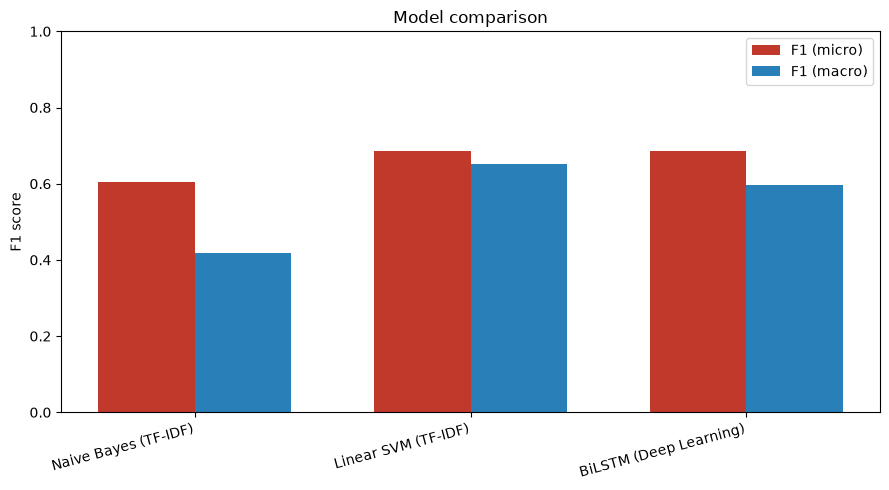

Best model by micro-F1: BiLSTM (Deep Learning)


In [8]:
import pandas as pd

scores = pd.read_csv("results/model_scores.csv")
cols = ["model","subset_accuracy","hamming_loss","f1_micro","f1_macro",
        "precision_micro","recall_micro"]
scores = scores[[c for c in cols if c in scores.columns]]
from IPython.display import display
display(scores)

x = range(len(scores)); w = 0.35
plt.figure(figsize=(9,5))
plt.bar([i-w/2 for i in x], scores["f1_micro"], w, label="F1 (micro)", color="#c0392b")
plt.bar([i+w/2 for i in x], scores["f1_macro"], w, label="F1 (macro)", color="#2980b9")
plt.xticks(list(x), scores["model"], rotation=15, ha="right")
plt.ylim(0,1); plt.ylabel("F1 score"); plt.title("Model comparison"); plt.legend()
plt.tight_layout(); plt.savefig("results/comparison_f1.png", dpi=120); plt.show()

best = scores.loc[scores["f1_micro"].idxmax(), "model"]
print("Best model by micro-F1:", best)

## 7. Try it on your own comment
Type any sentence and see what the model predicts.

In [9]:
from src.preprocessing import clean_text

def predict_comment(text, model_path="results/model_svm.joblib"):
    bundle = joblib.load(model_path)
    pred = bundle["pipeline"].predict([clean_text(text)])[0]
    result = {lab: int(v) for lab, v in zip(bundle["labels"], pred)}
    flagged = [k for k, v in result.items() if v == 1]
    print("Comment :", text)
    print("Result  :", result)
    print("Verdict :", "CYBERBULLYING -> " + ", ".join(flagged) if flagged else "Clean")
    return result

predict_comment("you are a stupid idiot, nobody likes you")

Comment : you are a stupid idiot, nobody likes you
Result  : {'abusive': 1, 'Race': 0, 'Religion': 0, 'Gender': 1, 'Sexual_Orientation': 0, 'Miscellaneous': 0}
Verdict : CYBERBULLYING -> abusive, Gender


{'abusive': 1,
 'Race': 0,
 'Religion': 0,
 'Gender': 1,
 'Sexual_Orientation': 0,
 'Miscellaneous': 0}